In [1]:
import atmPy.radiation.retrievals.broadband_shortwave_radiation as atmbsr
import surfradpy.database as srfdb

# Load file and make Broadband shortwave instance

In [2]:
db = srfdb.SurfradDatabase(srfdb.get_default_db_path())
siteinfo = db.find_site_info(abb = 'tbl')

In [3]:
p2fld = pl.Path('/Volumes/grad/surfrad/products_level1/radiation_netcdf/v1.1/tbl/2026/')

p2flist = list(p2fld.glob('*.nc'))

p2flist.sort()

In [4]:
# i = -1
# i +=1
# dso = xr.open_dataset(p2flist[i])
dso = xr.open_mfdataset(p2flist[14:16])

rename = {'dw_solar': 'global_horizontal',
          'diffuse' : 'diffuse_horizontal',
          'direct_n': 'direct_normal'}
ds = dso.rename_vars(rename)
ds.attrs['site'] = 'tbl'
ds.attrs['latitude'] = siteinfo.latitude
ds.attrs['longitude'] = siteinfo.longitude
ds.attrs['elevation'] = siteinfo.elevation

ds = ds.sel(datetime = slice('2026-01-15 12:00:00', '2026-01-16 02:00:00'))

In [5]:
reload(atmbsr)

<module 'atmPy.radiation.retrievals.broadband_shortwave_radiation' from '/Users/htelg/prog/atm-py/atmPy/radiation/retrievals/broadband_shortwave_radiation.py'>

/Users/htelg/prog/atm-py/atmPy/radiation/retrievals/broadband_shortwave_radiation.py:448: UserWarning: Clear_sky parameters have not been optimized! It is recommended to run optimize_clearsky_parameters().
  warnings.warn('Clear_sky parameters have not been optimized! It is recommended to run optimize_clearsky_parameters().')
/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/Users/htelg/miniconda3/envs/py13/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: invalid value encountered in power
  result_data = func(*input_data)


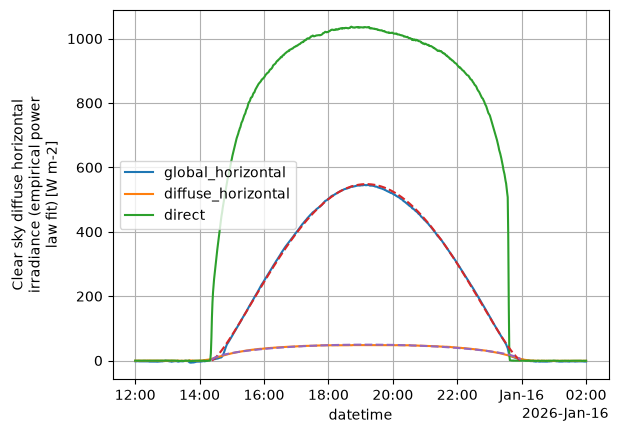

In [12]:
bsri = atmbsr.CombinedGlobalDiffuseDirect(ds)
self = bsri
f,a = bsri.plot_overview()
bsri.clearsky_global_horizontal.plot(ax = a, ls = '--')
bsri.clearsky_diffuse_horizontal.plot(ax = a, ls = '--')